In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from data_models import GaussianModel, MultimodalModel, MultiClassModel,TeacherStudentModel, exponential_covariance
from losses_regularizers import LogisticLoss, QuadraticRegularizer, PseudoHuberRegularizer,SquaredLoss,ElasticL1L2Loss
# from losses_regularizers import LogisticLoss, QuadraticRegularizer, PseudoHuberRegularizer,SquaredLoss,ElasticL1L2Loss
from erm_theory import ERMTrainer, TheoryFixedPointSolver

rng = np.random.default_rng(0)
rng2 = np.random.default_rng(1)


In [ ]:

c = 1
n = c * 50
p = c * 30



mu = np.zeros(p); 
theta_star = np.zeros(p)
nb_ones = 2*p//3
for i in range(nb_ones):
    theta_star[i] = 1
theta_star = 2*theta_star/np.linalg.norm(theta_star)
delta = np.zeros(p)
# for i in range(p):
for i in range(nb_ones+0):
    delta[i] = 1

pi = 0.4
models = dict()
model_names = ['Gaussian data', 'Non Gaussian data']
g1m1_x = GaussianModel(p=p, mu= pi*delta, C=0.15*np.eye(p))
g1m2_x = GaussianModel(p=p, mu= -(1-pi)*delta, C=0.15*np.eye(p))
mix_x = MultimodalModel(components=[g1m1_x, g1m2_x], weights=np.array([1-pi,pi]))


noise_std = 0.1
y_model = "linear_regression"
models['Non Gaussian data'] = TeacherStudentModel(
    x_model=mix_x,
    theta_teacher=theta_star,
    y_model=y_model,
    noise_std=noise_std,
)
mu = mix_x.params()['mu']
C = mix_x.params()['C']
models['Gaussian data'] = TeacherStudentModel(
    x_model=GaussianModel(p=p, mu= mu, C=C),
    theta_teacher=theta_star,
    y_model=y_model,
    noise_std=noise_std,
)
lam = 5
reg = QuadraticRegularizer(a=np.zeros(p), H= lam *np.eye(p))
models['Gaussian data'].validate_model_moments()
models['Non Gaussian data'].validate_model_moments()

--- Validating TeacherStudentModel ---
k    | gamma      | ||mu-mu_hat||  | ||C-C_hat||_F 
----------------------------------------------------
0    | 1.0000     | 3.2926e-02     | 5.6515e-02    
--- Validating TeacherStudentModel ---
k    | gamma      | ||mu-mu_hat||  | ||C-C_hat||_F 
----------------------------------------------------


0    | 1.0000     | 1.5556e-02     | 4.3156e-02    


In [7]:
nb_points = 20
ratio_th_emp = 1
nb_points_th = ratio_th_emp*(nb_points-1)+1
etas = np.linspace(1,0, nb_points)
etas_th = np.linspace(1,0, nb_points_th)
K = models['Gaussian data'].class_params()['num_classes']
fp_damping =0.1
fp_tol = 2e-5
fp_max_iter = 1000
mc_samples = 200000
num_trials = 70
n_test = 3000

vars = {'Gaussian data': {}, 'Non Gaussian data': {}}
for key in vars.keys():
    vars[key] = {
        'error_emp_means': [], 'error_emp_stds': [],
        'error_th': [], 'error_gaussian_score': [], 
        'nu': [],'mu': [], 'kappa': [], 
        'alpha': [], 'A': []
    }
var_fixed_pt = ['mu', 'nu', 'kappa', 'alpha', 'A']
thetas_rcrd = dict()
for (idx,eta) in enumerate(etas_th):
    loss = ElasticL1L2Loss(eta)
    if idx%ratio_th_emp ==0:
        
        print(f"\n===== etabda = {eta:g} (empirical gen reg) =====")

        for model_name in model_names:
            model = models[model_name]
            trainer = ERMTrainer(model=model, loss=loss, regularizer=reg)
            emp = trainer.run_trials(
                n_train=n,
                n_test=n_test,
                num_trials=num_trials,
                rng=rng,
                solver_maxiter=2000,
                tol=1e-6,
                method="L-BFGS-B",
                verbose=False,
            )
            if eta==0 or eta ==1:
                thetas_rcrd[(model_name, int(eta))] = emp['thetas']
            vars[model_name]['error_emp_means'].append(emp["gen_loss_mean"])
            vars[model_name]['error_emp_stds'].append(emp["gen_loss_std"])
            print(f"Empirical loss for {model_name}: mean={emp['gen_loss_mean']:.6f}  std={emp['gen_loss_std']:.6f}")


    print(f"\n===== etabda = {eta:g} (theory) =====")
    for model_name in model_names:
        model = models[model_name]
        solver = TheoryFixedPointSolver(
            model=model,
            loss=loss,
            regularizer=reg,
            n_train=n,
            mc_samples=mc_samples,  # more samples for smaller etabda
            rng=np.random.default_rng(123),  # fixed for repeatability
        )

        th = solver.solve(
            max_iter=1000,
            tol= fp_tol,
            damping=np.max([lam,1]) * fp_damping,
            verbose=False,
            mu0=vars[model_name]['mu'][-1] if idx>0 else None,
            alpha0=vars[model_name]['alpha'][-1] if idx>0 else None,
            nu0=[1/(1+vars[model_name]['kappa'][-1][cl]) for cl in range(K)] if idx>0 else None,
        )

        vars[model_name]['error_th'].append(th["predicted_loss"])

        # Warm start for next etabda
        for var in var_fixed_pt:
            vars[model_name][var].append(th[var])
        print(f"Theory predicted loss for {model_name} model: {th['predicted_loss']:.6f}  (converged={th['converged']}, iters={th['num_iter']}, damping_final={th.get('damping_final', float('nan')):.3f})")
        
        # Prediction under score universality (can not use th['predicted_loss_gaussian_score'] directly in regression settings since y can take multiple values)
        z_samples = rng.standard_normal(size=100000)
        proj = (vars[model_name]['mu'][-1]-theta_star).reshape(-1,1)
        mu_x = model.x_model.params().get('mu', None)
        C_x = model.x_model.params().get('C', None)
        err_gauss_score_sple = proj.T@ mu_x+ np.sqrt(proj.T @ C_x @ proj + float(vars[model_name]['alpha'][-1][0])**2) * z_samples
        err_gauss_score = float(np.mean(loss.value(err_gauss_score_sple, 0)))
        vars[model_name]['error_gaussian_score'].append(err_gauss_score)
        print(f"Theory predicted for {model_name} under score universality: {err_gauss_score:.6f}")




===== etabda = 1 (empirical gen reg) =====


Empirical loss for Gaussian data: mean=2.916730  std=0.082461
Empirical loss for Non Gaussian data: mean=3.373668  std=0.042614

===== etabda = 1 (theory) =====
Theory predicted loss for Gaussian data model: 2.923107  (converged=True, iters=98, damping_final=0.051)
Theory predicted for Gaussian data under score universality: 2.924073
Theory predicted loss for Non Gaussian data model: 3.372856  (converged=True, iters=110, damping_final=0.048)
Theory predicted for Non Gaussian data under score universality: 2.783994

===== etabda = 0.947368 (empirical gen reg) =====
Empirical loss for Gaussian data: mean=2.982885  std=0.120495
Empirical loss for Non Gaussian data: mean=3.380157  std=0.060202

===== etabda = 0.947368 (theory) =====
Theory predicted loss for Gaussian data model: 2.990131  (converged=True, iters=105, damping_final=0.049)
Theory predicted for Gaussian data under score universality: 2.995228
Theory predicted loss for Non Gaussian data model: 3.382516  (converged=True, iters=1

In [ ]:
cl=0
num_trials_th = 100000
scores_emp = dict()
scores_th = dict()
z_samples = rng2.standard_normal(size=num_trials_th) 
for idx,eta in zip([0,-1],[1,0]):
# for idx,eta in zip([0,-1],[1,0]):
    for model_name in ['Gaussian data','Non Gaussian data']:
        sc_emp=[]
        for i in range(num_trials):
            Xte, yte = models[model_name].sample_class(cl, n_test, rng=rng)
            sc_emp += [Xte[j]@(thetas_rcrd[(model_name, eta)][i]-theta_star) for j in range(n_test)]
        scores_emp[(model_name, eta)] = np.array(sc_emp)
        Xtetst, ytetst = models[model_name].sample_class(cl,num_trials_th, rng=rng2)
        scores_th[(model_name, eta)] = Xtetst@(vars[model_name]["mu"][idx]-theta_star) + vars[model_name]["alpha"][idx][cl]*z_samples
        # scores_th[(model_name, eta)] = Xtetst@(vars[model_name]["mu"][idx]-theta_star) + vars[model_name]["alpha"][idx][cl]*z_samples

/tmp/ipykernel_165799/1366763874.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


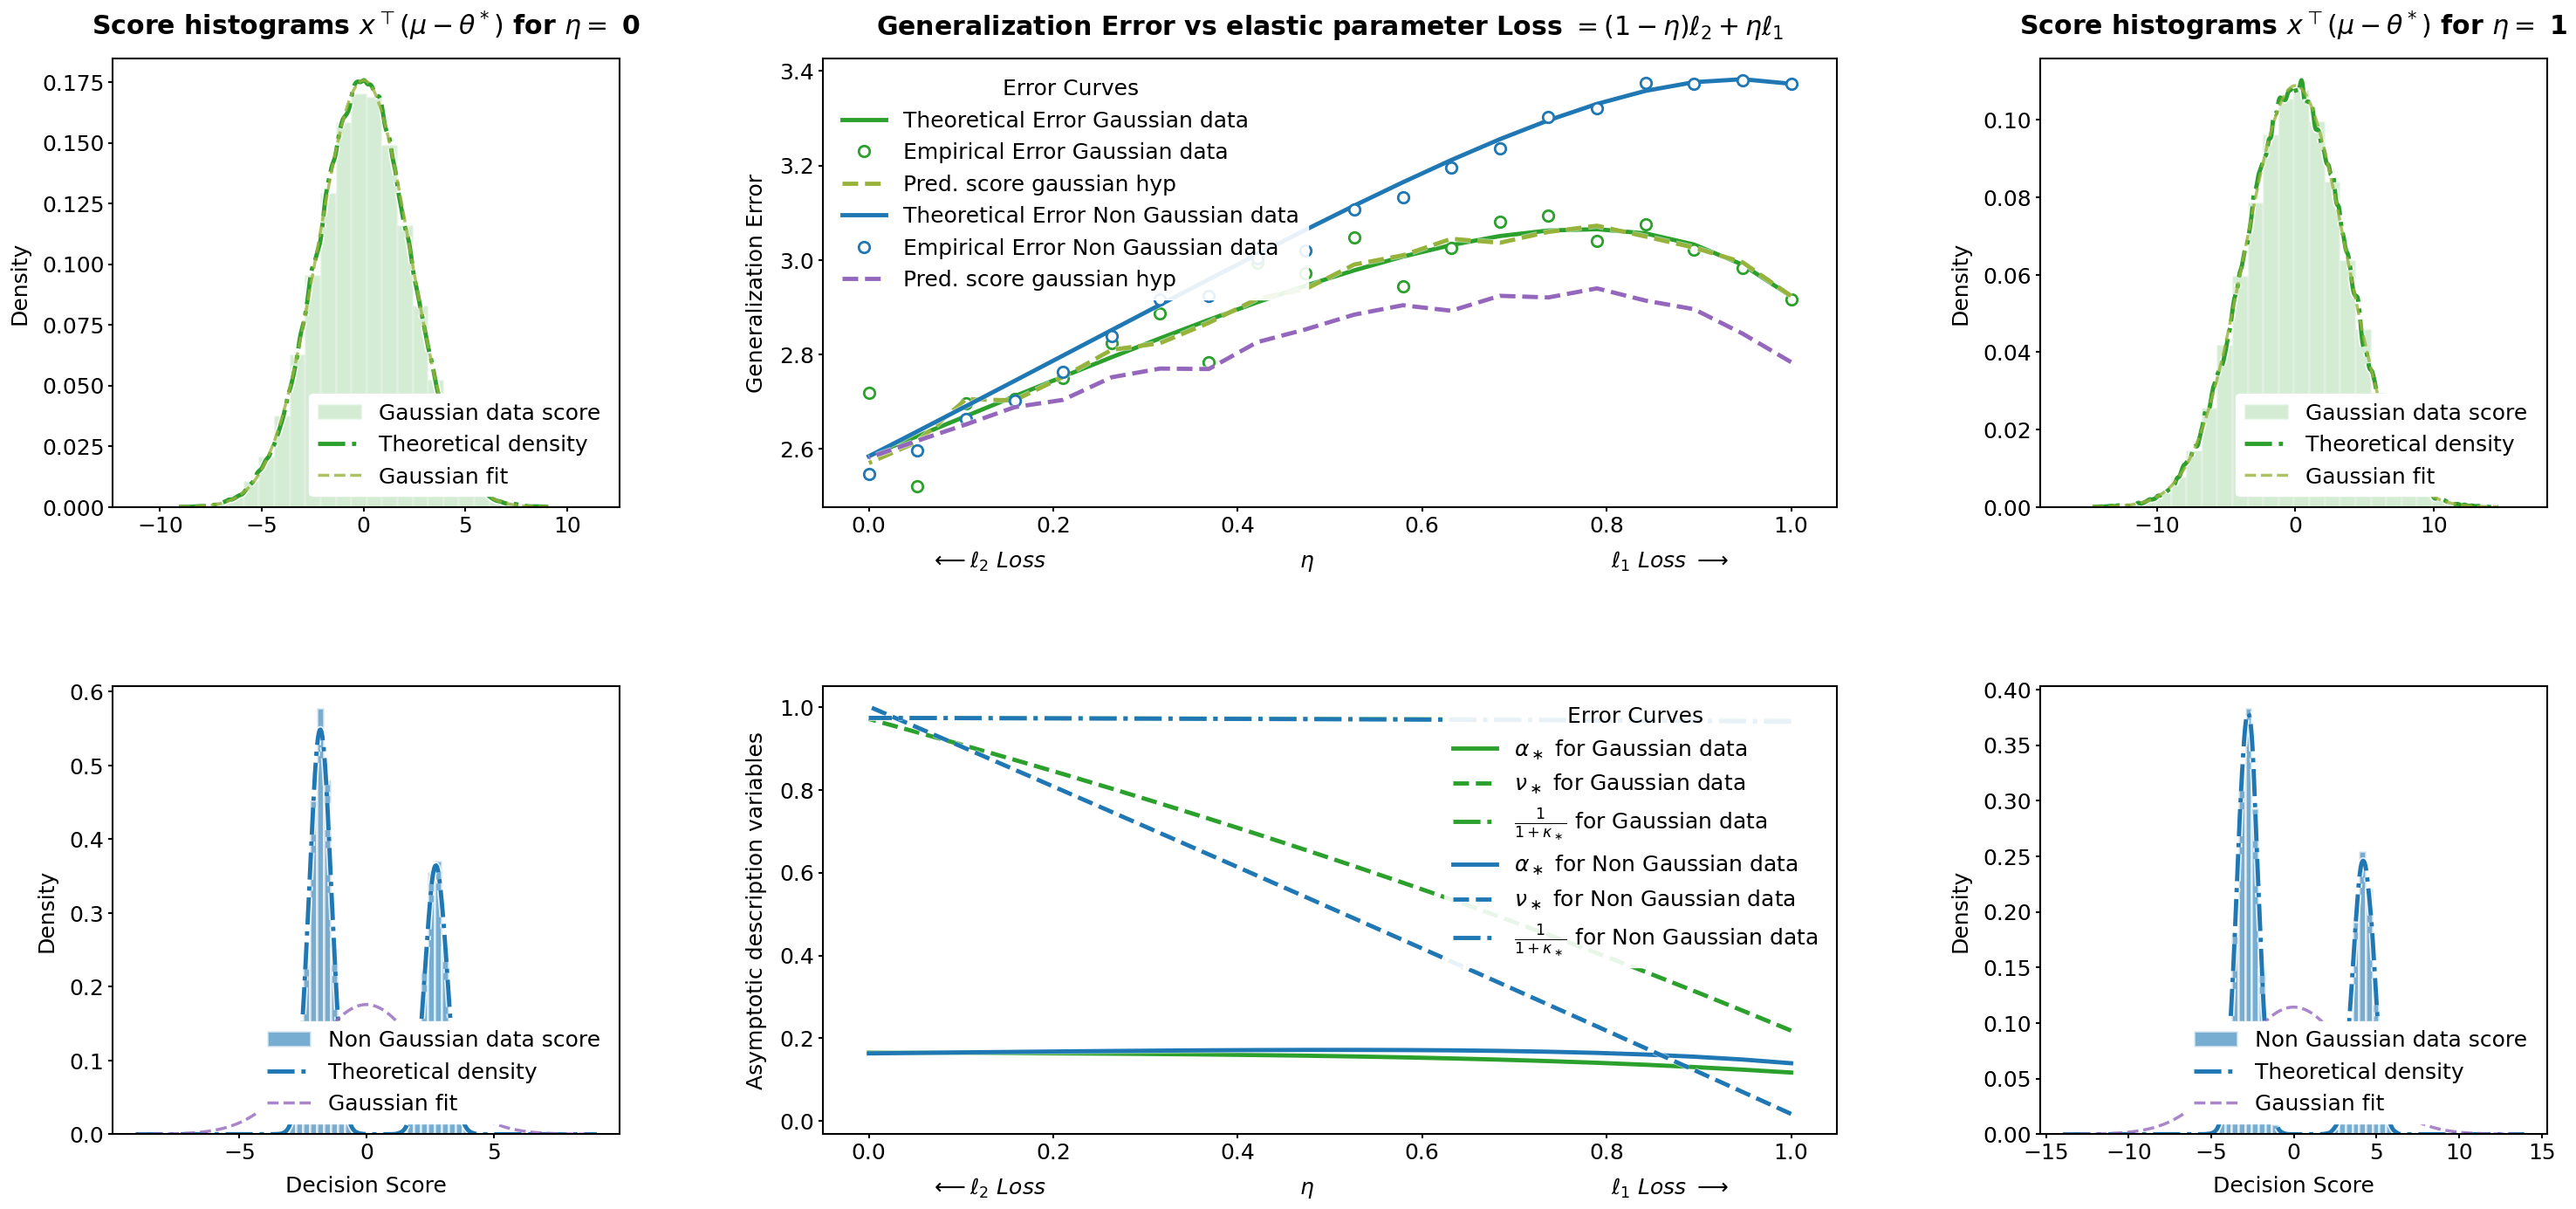

In [ ]:

# --- Reset font settings for a modern, clean look ---
from matplotlib import patheffects
from sklearn.neighbors import KernelDensity
from scipy.stats import norm
from matplotlib.gridspec import GridSpec
import logging

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# --- PLOT SETTINGS ---
plt.rcParams['text.usetex'] = False
plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5


colors = {
    'Gaussian data':{
        'raw_score': '#2CA02C',
        'score_univ': "#97B33C",
    },
    'Non Gaussian data':
    {
        'raw_score': '#1F77B4',
        'score_univ': '#9467BD',
    },
}


# --- Create the figure ---
fig = plt.figure(figsize=(36, 16))

gs = GridSpec(
    nrows=2,
    ncols=3,
    height_ratios=[1, 1],  # adjust if needed
    width_ratios=[1, 2, 1],  # adjust if needed
    hspace=0.4,
    wspace=0.3
)

axes_histo = {0: {'Gaussian data' : fig.add_subplot(gs[0, 0]), 'Non Gaussian data': fig.add_subplot(gs[1, 0])},
              1: {'Gaussian data' : fig.add_subplot(gs[0, 2]), 'Non Gaussian data': fig.add_subplot(gs[1, 2])}}

ax_mid_upper  = fig.add_subplot(gs[0, 1])
ax_mid_bottom = fig.add_subplot(gs[1, 1])

# Bottom: spans both columns
# --- LEFT PANEL: Histograms + PDFs ---
c_label=0
alpha = {'Non Gaussian data':0.6,'Gaussian data':0.2}
for eta in [0,1]:
    for model_name in model_names:
        axes_histo[eta][model_name].hist(
            scores_emp[(model_name, eta)],
            bins=30,
            density=True,
            alpha=alpha[model_name],
            color=colors[model_name]['raw_score'],
            edgecolor='white',
            linewidth=2,
            label=f'{model_name} score' 
        )
        scth = scores_th[(model_name, eta)]
        x = np.linspace(np.mean(scth) - 4 * np.std(scth), np.mean(scth) + 4 * np.std(scth), 500)
        kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(scth.reshape(-1, 1))
        log_dens = kde.score_samples(x.reshape(-1, 1))
        axes_histo[eta][model_name].plot(
            x,
            np.exp(log_dens),
            color=colors[model_name]['raw_score'],
            linewidth=3.5,
            linestyle='-.',
            label=f'Theoretical density',
            path_effects=[patheffects.withStroke(linewidth=6, foreground='white', alpha=0.8)]
        )
        axes_histo[eta][model_name].plot(
            x,
            norm.pdf(x, np.mean(scth),  np.std(scth)),
            linestyle='--',
            color=colors[model_name]['score_univ'],
            linewidth=2.5,
            label=f'Gaussian fit',
            alpha=0.8
        )

    axes_histo[eta]['Gaussian data'].set_title(r"Score histograms $x^\top(\mu-\theta^*)$ for $\eta =$ {eta}".format(eta=eta), pad=20, fontweight='bold')
    axes_histo[eta]['Non Gaussian data'].set_xlabel("Decision Score", labelpad=10)
    for model_name in model_names:
        axes_histo[eta][model_name].set_ylabel("Density", labelpad=10)
        axes_histo[eta][model_name].legend(loc='lower right', frameon=True, framealpha=1, edgecolor='white')


# --- MIDDLE UPPER PANEL: Classification Error ---
for model_name in model_names:

    ax_mid_upper.plot(
        etas_th,
        vars[model_name]['error_th'],
        color=colors[model_name]['raw_score'],
        linewidth=3.5,
        label=f'Theoretical Error {model_name}',
        path_effects=[patheffects.withStroke(linewidth=5, foreground='white', alpha=0.5)]
    )
    ax_mid_upper.plot(
        etas,
        vars[model_name]['error_emp_means'],
        color=colors[model_name]['raw_score'],
        linestyle ='none',
        linewidth=3.5,
        label=f'Empirical Error {model_name}',
        marker='o',
        markersize=9,
        markerfacecolor='white',
        markeredgewidth=2,
        markeredgecolor=colors[model_name]['raw_score']
        # colors['empirical']
    )
    ax_mid_upper.plot(
        etas_th,
        vars[model_name]['error_gaussian_score'],
        color=colors[model_name]['score_univ'],
        linestyle ='--',
        linewidth=3.5,
        label=f'Pred. score gaussian hyp',
        path_effects=[patheffects.withStroke(linewidth=5, foreground='white', alpha=0.5)]
    )

# --- Styling ---
ax_mid_upper.set_title(r"Generalization Error vs elastic parameter Loss $= (1- \eta) \ell_2 + \eta \ell_1$", pad=20, fontweight='bold')
ax_mid_upper.set_xlabel(r"$\longleftarrow \ell_2 \  Loss  \qquad \qquad \qquad \qquad \qquad \qquad\eta \qquad \qquad \qquad \qquad \qquad \qquad \qquad \ell_1 \  Loss \ \longrightarrow $", labelpad=10)
ax_mid_upper.set_ylabel("Generalization Error", labelpad=10)
ax_mid_upper.legend(loc='upper left', frameon=True, framealpha=0.9, edgecolor='white', title='Error Curves')
# ax_mid_upper.grid(True, linestyle='-', color=colors['grid'], alpha=0.3)

# --- MIDDLE BOTTOM PANEL: fixed point quantities ---
display_vars =['alpha', 'nu', '1/(1+kappa)']
linestyle ={'alpha':'-', 'nu':'--', '1/(1+kappa)': '-.'}
labels ={'alpha':r'$\alpha_\ast$', 'nu':r'$\nu_\ast$', '1/(1+kappa)': r'$\frac{1}{1+\kappa_\ast}$'}
for model_name in model_names:
    vars[model_name]['1/(1+kappa)'] = [1/(1+kap) for kap in vars[model_name]['kappa']]
    for var in display_vars:
        ax_mid_bottom.plot(
            etas_th,
            vars[model_name][var],
            color=colors[model_name]['raw_score'],
            linewidth=3.5,
            linestyle = linestyle[var],
            label=f'{labels[var]} for {model_name}',
            path_effects=[patheffects.withStroke(linewidth=5, foreground='white', alpha=0.5)]
        )



# --- Styling ---
ax_mid_bottom.set_title("", pad=20, fontweight='bold')
ax_mid_bottom.set_xlabel(r"$\longleftarrow \ell_2 \  Loss  \qquad \qquad \qquad \qquad \qquad \qquad\eta \qquad \qquad \qquad \qquad \qquad \qquad \qquad \ell_1 \  Loss \ \longrightarrow $", labelpad=10)
ax_mid_bottom.set_ylabel("Asymptotic description variables", labelpad=10)
ax_mid_bottom.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='white', title='Error Curves')
# ax_mid_bottom.grid(True, linestyle='-', color=colors['grid'], alpha=0.3)


# --- Save in high quality ---
plt.tight_layout()
# fig.savefig("ICML_teaser_figure.pdf", bbox_inches='tight', dpi=1200, transparent=True)
# fig.savefig("ICML_teaser_figure.png", bbox_inches='tight', dpi=1200, transparent=True)
plt.show()
